In [1]:
!echo $CONDA_DEFAULT_ENV

jsc


In [2]:
import glob
import math
import os
import random
import re
import sys
import unicodedata
from difflib import SequenceMatcher
from math import asin, cos, radians, sin, sqrt
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cf_xarray
import cordex as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import seaborn as sns
import unidecode
import xarray as xr
import xesmf as xe
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from shapely import contains_xy, vectorized
from shapely.geometry import Point

from evaltools.source import xarray_open_kwargs
from tools import (
    check_equal_period,
    fix_360_longitudes,
    open_datasets,
    standardize_unit,
)
from urclimask.GHCNd_stations import get_valid_timeseries, inside_city
from urclimask.UHI_analysis import UrbanIsland
from urclimask.urban_areas import UrbanVicinity, plot_urban_polygon
from urclimask.utils import load_ucdb_city, traverseDir

In [3]:
# =============================================================================
# GEOSPATIAL CALCULATIONS
# =============================================================================

def haversine_distance(lon1, lat1, lon2, lat2):
    """
    Calculate the great-circle distance in kilometers between two points 
    on the Earth using the Haversine formula. 
    Supports both scalar values and NumPy arrays.
    """
    R = 6371  # Earth radius in kilometers
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

# =============================================================================
# XARRAY AND CORDEX UTILITIES
# =============================================================================

def create_urban_mask(ds: xr.Dataset, polygon, var_name: str = "urmask") -> xr.DataArray:
    """
    Create an urban mask (1 for cells inside the polygon, 0 otherwise) 
    for the grid defined by the input Dataset.
    """
    lats = ds.lat.values
    lons = ds.lon.values

    # Initialize mask array with zeros
    mask = np.zeros((len(lats), len(lons)), dtype=np.int16)

    # Simple nested loop iteration for masking
    for i, la in enumerate(lats):
        for j, lo in enumerate(lons):
            if polygon.contains(Point(lo, la)):
                mask[i, j] = 1

    return xr.DataArray(mask, coords=[("lat", lats), ("lon", lons)], name=var_name)

def create_cordex_grid(domain_id: str) -> xr.Dataset:
    """
    Generate an Xarray Dataset containing a CORDEX grid definition 
    including 2D coordinates and boundary vertices.
    """
    grid = cx.domain(domain_id, bounds=True, mip_era="CMIP6")
    
    # Calculate corner vertices from bounds arrays
    lon_b = cf_xarray.bounds_to_vertices(
        grid.vertices_lon, bounds_dim="vertices", order="counterclockwise"
    )
    lat_b = cf_xarray.bounds_to_vertices(
        grid.vertices_lat, bounds_dim="vertices", order="counterclockwise"
    )
    
    return grid.assign_coords(
        lon_b=(("y", "x", "vertices"), lon_b.values), 
        lat_b=(("y", "x", "vertices"), lat_b.values)
    )

def count_urban_cells(file: str) -> int:
    """
    Count the number of urban cells (where 'urmask' equals 1) in a NetCDF file.
    """
    with xr.open_dataset(file) as ds:
        urmask = ds['urmask'].values
        return int(np.sum(urmask == 1))

def get_lat_lon_names(ds: xr.Dataset) -> tuple[str, str]:
    """
    Detect the names of latitude and longitude coordinates in the Dataset 
    based on common NetCDF/CORDEX conventions.
    """
    lon_candidates = ["lon", "longitude", "nav_lon", "x", "rlon"]
    lat_candidates = ["lat", "latitude", "nav_lat", "y", "rlat"]
    
    lon_name = next((c for c in lon_candidates if c in ds.coords), None)
    lat_name = next((c for c in lat_candidates if c in ds.coords), None)
    
    if not lon_name or not lat_name:
        raise KeyError(f"Could not find lon/lat coordinates in Dataset. Available: {list(ds.coords)}")
    
    return lat_name, lon_name

# =============================================================================
# TEXT AND NAME NORMALIZATION UTILITIES
# =============================================================================

def clean_text(s: str) -> str:
    """
    Remove invisible characters, Byte Order Marks (BOM), and 
    zero-width spaces from a string.
    """
    if s is None or pd.isna(s):
        return ""
    s = str(s).replace("\ufeff", "")
    s = re.sub(r"[\u200B-\u200D\uFEFF]", "", s)
    return s.strip()

def strip_bom(x):
    """Simple wrapper to strip BOM from strings."""
    if isinstance(x, str):
        return x.replace("\ufeff", "").strip()
    return x

def safe_name(name: str) -> str:
    """
    Normalize city names for simple matching: lowercase, 
    remove accents, and collapse multiple spaces.
    """
    if name is None or pd.isna(name):
        return ""
    name = clean_text(name)
    name = re.sub(r'\s+', ' ', name)
    name = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('ascii')
    return name.lower().strip()

def canonicalize(s: str) -> str:
    """
    Aggressive normalization for robust fuzzy name matching: 
    removes punctuation, accents, and converts to lowercase.
    """
    if s is None or pd.isna(s):
        return ""
    s = str(s).lower().strip()
    s = unicodedata.normalize('NFKD', s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = re.sub(r'[_\[\]\(\)/\\]', ' ', s)
    s = re.sub(r'[^\w\s]', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()

def normalize_text(s: str) -> str:
    """
    Strong normalization: removes accents, converts to lowercase, 
    and replaces all whitespace/separators with single underscores.
    """
    if pd.isna(s):
        return ""
    s = clean_text(s)
    s = unidecode.unidecode(s)
    s = s.lower().replace("-", " ")
    return "_".join(s.split())

def sanitize_filename(name: str) -> str:
    """
    Convert a string into a filesystem-safe format by 
    replacing special characters with underscores.
    """
    name = clean_text(name)
    return re.sub(r"[^\w\-]", "_", name)

def normalize_name(x) -> str | None:
    """
    Apply canonicalization and sanitization steps to generate 
     a cleaned, normalized name.
    """
    if pd.isna(x):
        return None
    return clean_text(sanitize_filename(x)).lstrip("_")

## Parameters

In [4]:
urban_var = "sfturf"

urban_sur_th = 5
orog_diff = 100
sftlf_th = 70
ratio_r2u = 2
min_city_size = 20
lon_lim = 1
lat_lim = 1

variable = "tasmin"
period_star = "1991"
period_stop = "2020"
period = slice(period_star, period_stop)

mip_era = "CMIP6"
driving_source_id = "ERA5"
frequency = "mon"
variable= 'tasmin'
domain = "EUR-11"
model = "REMO"
domain_resolution = int(domain.split("-")[1])

In [5]:
output_folder = "urban_th_sensitivity"
os.makedirs(output_folder, exist_ok=True)  # crea carpeta si no existe

### Load the data

In [6]:
catalog_path = "catalog.xlsx"

df = pd.read_excel(catalog_path)
source_ids = df["source_id"].dropna().unique().tolist()

In [7]:
xarray_open_kwargs['chunks'] = {'time': 160}

dsets = open_datasets(
    [variable],
    frequency=frequency,
    driving_source_id=driving_source_id,
    mask=True,
    add_missing_bounds=False, 
    source_id = source_ids
)

Opening catalog from https://euro-cordex.s3.eu-central-1.amazonaws.com/catalog/CORDEX-CMIP6-JSC.json
Found 17 source ids for variables ['tasmin']: ['RACMO23E', 'ICON-CLM-202407-1-1', 'CCLM6-0-1', 'CCLM6-0-1-URB', 'HCLIM43-ALADIN', 'ROAM-NBS', 'HadREM3-GA7-05', 'REMO2020-2-2-iMOVE-LUC', 'REMO2020-2-2-MR2', 'REMO2020-2-2-TEB', 'REMO2020-2-2', 'REMO2020-2-2-iMOVE', 'WRF451Q', 'CCLM6-0-1-URB-ESG', 'CNRM-ALADIN64E1', 'RegCM5-0', 'ALARO1-SFX']

--> The keys in the returned dictionary of datasets are constructed as follows:
	'project_id.domain_id.institution_id.driving_source_id.driving_experiment_id.driving_variant_label.source_id.version_realization.frequency.version'


decoding dataset CORDEX-CMIP6.EUR-12.CLMcom-CMCC.ERA5.evaluation.r1i1p1f1.CCLM6-0-1-URB.v1-r1.fx.v20250201
Found 38 datasets
decoding dataset CORDEX-CMIP6.EUR-12.CESAM-UA.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r2.fx.v20250630
Warning for CORDEX-CMIP6.EUR-12.CESAM-UA.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r2.fx.v20250630: Variable(s) referenced in cell_measures not in variables: ['areacella']
Warning for CORDEX-CMIP6.EUR-12.CESAM-UA.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r2.fx.v20250630: Variable(s) referenced in cell_measures not in variables: ['areacella']
Warning for CORDEX-CMIP6.EUR-12.CESAM-UA.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r2.fx.v20250630: Variable(s) referenced in cell_measures not in variables: ['areacella']
Found 38 datasets
decoding dataset CORDEX-CMIP6.EUR-12.DWD-BSH.ERA5.evaluation.r1i1p1f1.ROAM-NBS.v1-r1.fx.v20240920
Warning for CORDEX-CMIP6.EUR-12.DWD-BSH.ERA5.evaluation.r1i1p1f1.ROAM-NBS.v1-r1.fx.v20240920: Variable(s) referenced in cell_measures not in variables: ['areacella

/mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/evaltools/evaltools/fix.py:93: UserWarning: Grid mapping has (198.0, 39.25) which is inconsistent with (-162.0, 39.25) for EUR-12 and CORDEX-CMIP6.EUR-12.MOHC.ERA5.evaluation.r1i1p1f1.HadREM3-GA7-05.v1-r1.fx.v20260219.
  warnings.warn(message)
/mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/evaltools/evaltools/fix.py:139: UserWarning: Renaming X and Y axis to be named rlon and rlat for rotated_latitude_longitude grid mapping: CORDEX-CMIP6.EUR-12.MOHC.ERA5.evaluation.r1i1p1f1.HadREM3-GA7-05.v1-r1.fx.v20260219
  warnings.warn(
/mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/evaltools/evaltools/fix.py:151: UserWarning: Renaming coordinates longitude and latitude to be named lon and lat: CORDEX-CMIP6.EUR-12.MOHC.ERA5.evaluation.r1i1p1f1.HadREM3-GA7-05.v1-r1.fx.v20260219
  warnings.warn(
/mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/evaltools/evaltools/fix.py:93: UserWarning: Grid mapping has (198.0, 39.25) which is inconsistent with (-162.0, 39.25) for EUR-12 and CORD

Renaming grid mapping variable rotated_latitude_longitude to 'crs' for CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-TEB.v1-r1.fx.v20251028
Renaming grid mapping variable rotated_latitude_longitude to 'crs' for CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2.v1-r1.fx.v20241120
Renaming grid mapping variable rotated_latitude_longitude to 'crs' for CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-iMOVE.v1-r1.fx.v20250515


/mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/evaltools/evaltools/fix.py:100: UserWarning: fx variable should not contain time dimension: CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.CCLM6-0-1.v1-r1.fx.v20230222
  warnings.warn(f"fx variable should not contain time dimension: {iid}")
/mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/evaltools/evaltools/fix.py:101: UserWarning: Trying to drop time dimension from fx variable: CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.CCLM6-0-1.v1-r1.fx.v20230222
  warnings.warn(f"Trying to drop time dimension from fx variable: {iid}")


...

Renaming grid mapping variable rotated_latitude_longitude to 'crs' for CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-iMOVE-LUC.v1-r1.mon.v20250515
Renaming grid mapping variable rotated_latitude_longitude to 'crs' for CORDEX-CMIP6.EUR-12.MOHC.ERA5.evaluation.r1i1p1f1.HadREM3-GA7-05.v1-r1.mon.v20260219


/mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/evaltools/evaltools/fix.py:93: UserWarning: Grid mapping has (198.0, 39.25) which is inconsistent with (-162.0, 39.25) for EUR-12 and CORDEX-CMIP6.EUR-12.MOHC.ERA5.evaluation.r1i1p1f1.HadREM3-GA7-05.v1-r1.mon.v20260219.
  warnings.warn(message)
/mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/evaltools/evaltools/fix.py:139: UserWarning: Renaming X and Y axis to be named rlon and rlat for rotated_latitude_longitude grid mapping: CORDEX-CMIP6.EUR-12.MOHC.ERA5.evaluation.r1i1p1f1.HadREM3-GA7-05.v1-r1.mon.v20260219
  warnings.warn(
/mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/evaltools/evaltools/fix.py:151: UserWarning: Renaming coordinates longitude and latitude to be named lon and lat: CORDEX-CMIP6.EUR-12.MOHC.ERA5.evaluation.r1i1p1f1.HadREM3-GA7-05.v1-r1.mon.v20260219
  warnings.warn(


Renaming grid mapping variable rotated_pole to 'crs' for CORDEX-CMIP6.EUR-12.AUTH.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r3.mon.v20250630
Renaming grid mapping variable rotated_pole to 'crs' for CORDEX-CMIP6.EUR-12.IDL-FCUL.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r1.mon.v20240630


/mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/evaltools/evaltools/fix.py:93: UserWarning: Grid mapping has (18.0, 39.25) which is inconsistent with (-162.0, 39.25) for EUR-12 and CORDEX-CMIP6.EUR-12.AUTH.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r3.mon.v20250630.
  warnings.warn(message)


merging CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-MR2.v1-r1.mon.v20241120 with CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-MR2.v1-r1.fx.v20241120
merging CORDEX-CMIP6.EUR-12.CESAM-UA.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r2.mon.v20250630 with CORDEX-CMIP6.EUR-12.CESAM-UA.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r2.fx.v20250630
merging CORDEX-CMIP6.EUR-12.HCLIMcom-SMHI.ERA5.evaluation.r1i1p1f1.HCLIM43-ALADIN.v1-r1.mon.v20241205 with CORDEX-CMIP6.EUR-12.HCLIMcom-SMHI.ERA5.evaluation.r1i1p1f1.HCLIM43-ALADIN.v1-r1.fx.v20241205
merging CORDEX-CMIP6.EUR-12.CLMcom-CMCC.ERA5.evaluation.r1i1p1f1.CCLM6-0-1-URB.v1-r1.mon.v20250201 with CORDEX-CMIP6.EUR-12.CLMcom-CMCC.ERA5.evaluation.r1i1p1f1.CCLM6-0-1-URB.v1-r1.fx.v20250201
merging CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.ICON-CLM-202407-1-1.v1-r1.mon.v20240920 with CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.ICON-CLM-202407-1-1.v1-r1.fx.v20240920
merging CORDEX-CMIP6.EUR-12.KN

In [8]:
# delete simulatios with not urban static variable
to_delete = [dset for dset, ds in dsets.items() if urban_var not in ds.variables]

for dset in to_delete:
    del dsets[dset]

In [9]:
for dset in dsets.keys():
    dsets[dset] = dsets[dset].sel(time=period)

In [10]:
for dset in dsets.keys():
    if not check_equal_period(dsets[dset], period):
        print(f"Temporal coverage of {dset} does not match with {period}")

Temporal coverage of CORDEX-CMIP6.EUR-12.MOHC.ERA5.evaluation.r1i1p1f1.HadREM3-GA7-05.v1-r1.mon.v20260219 does not match with slice('1991', '2020', None)


In [11]:
dsets.keys()

dict_keys(['CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-MR2.v1-r1.mon.v20241120', 'CORDEX-CMIP6.EUR-12.CESAM-UA.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r2.mon.v20250630', 'CORDEX-CMIP6.EUR-12.HCLIMcom-SMHI.ERA5.evaluation.r1i1p1f1.HCLIM43-ALADIN.v1-r1.mon.v20241205', 'CORDEX-CMIP6.EUR-12.CLMcom-CMCC.ERA5.evaluation.r1i1p1f1.CCLM6-0-1-URB.v1-r1.mon.v20250201', 'CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.ICON-CLM-202407-1-1.v1-r1.mon.v20240920', 'CORDEX-CMIP6.EUR-12.KNMI.ERA5.evaluation.r1i1p1f1.RACMO23E.v1-r1.mon.v20241216', 'CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2.v1-r1.mon.v20241120', 'CORDEX-CMIP6.EUR-12.MOHC.ERA5.evaluation.r1i1p1f1.HadREM3-GA7-05.v1-r1.mon.v20260318', 'CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-TEB.v1-r1.mon.v20251028', 'CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-iMOVE.v1-r1.mon.v20250515', 'CORDEX-CMIP6.EUR-12.ICTP.ERA5.evaluation.r1i1p1f1.RegCM5-0.v1-r1.mon.v2025

In [12]:
dsets.pop("CORDEX-CMIP6.EUR-12.MOHC.ERA5.evaluation.r1i1p1f1.HadREM3-GA7-05.v1-r1.mon.v20260219", None)
dsets.pop("CORDEX-CMIP6.EUR-12.CESAM-UA.ERA5.evaluation.r1i1p1f1.WRF451Q.v1-r2.mon.v20250630", None)
dsets.pop("CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-MR2.v1-r1.mon.v20241120", None)

for dset in dsets.keys():
    print(dset)
    dsets[dset] = standardize_unit(dsets[dset], variable)

CORDEX-CMIP6.EUR-12.HCLIMcom-SMHI.ERA5.evaluation.r1i1p1f1.HCLIM43-ALADIN.v1-r1.mon.v20241205
CORDEX-CMIP6.EUR-12.CLMcom-CMCC.ERA5.evaluation.r1i1p1f1.CCLM6-0-1-URB.v1-r1.mon.v20250201
CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.ICON-CLM-202407-1-1.v1-r1.mon.v20240920
CORDEX-CMIP6.EUR-12.KNMI.ERA5.evaluation.r1i1p1f1.RACMO23E.v1-r1.mon.v20241216
CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2.v1-r1.mon.v20241120
CORDEX-CMIP6.EUR-12.MOHC.ERA5.evaluation.r1i1p1f1.HadREM3-GA7-05.v1-r1.mon.v20260318
CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-TEB.v1-r1.mon.v20251028
CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-iMOVE.v1-r1.mon.v20250515
CORDEX-CMIP6.EUR-12.ICTP.ERA5.evaluation.r1i1p1f1.RegCM5-0.v1-r1.mon.v20250415
CORDEX-CMIP6.EUR-12.CLMcom-KUL.ERA5.evaluation.r1i1p1f1.CCLM6-0-1-URB-ESG.v1-r1.mon.v20260305
CORDEX-CMIP6.EUR-12.DWD-BSH.ERA5.evaluation.r1i1p1f1.ROAM-NBS.v1-r1.mon.v20240920
CORDEX-CMIP6.EUR-12.CNRM-MF.ERA5

### Load the cities

In [13]:
# Define paths for auxiliary data and UCDB geopackage
root_aux_data = "/mnt/CORDEX_CMIP6_tmp/aux_data/"
ucdb_path = f"{root_aux_data}GHS_FUA_UCD/GHS_UCDB_GLOBE_R2024A.gpkg"

# Load UCDB centroids and general characteristics layers
gdf_centroids = gpd.read_file(ucdb_path, layer="UC_centroids")
gdf_char = gpd.read_file(ucdb_path, layer="GHS_UCDB_THEME_GENERAL_CHARACTERISTICS_GLOBE_R2024A")

# Clean column names (remove leading/trailing spaces or hidden characters)
gdf_centroids.columns = gdf_centroids.columns.str.strip().str.replace("﻿", "", regex=True)
gdf_char.columns = gdf_char.columns.str.strip().str.replace("﻿", "", regex=True)

# Reproject centroids to WGS84 (EPSG:4326) for latitude/longitude coordinates
gdf_centroids = gdf_centroids.to_crs(epsg=4326)

# Merge centroids geometry with general characteristics using ID_UC_G0 as key
gdf_merged = gdf_char.merge(
    gdf_centroids[["ID_UC_G0", "geometry"]],
    on="ID_UC_G0"
)

# Set the merged geometry to the centroid geometry (geometry_y)
gdf_merged = gdf_merged.set_geometry("geometry_y")

# Extract longitude and latitude for filtering
lon_tmp = gdf_merged.geometry.x
lat_tmp = gdf_merged.geometry.y

# Filter cities by minimum area (12x12 km² = 144 km²)
gdf_filtered = gdf_merged[gdf_merged["GC_UCA_KM2_2025"] >= 12.5*12.5].copy()

# Filter by bounding box covering Europe
gdf_europe = gdf_filtered[
    (lat_tmp >= 34) & (lat_tmp <= 72) &
    (lon_tmp >= -25) & (lon_tmp <= 45)
].copy()

# Display the number of filtered cities and a preview of selected columns
print(f"Filtered cities in Europe >=144 km²: {len(gdf_europe)}")
print(gdf_europe[["ID_UC_G0", "GC_UCA_KM2_2025"]].head())

Filtered cities in Europe >=144 km²: 95
     ID_UC_G0  GC_UCA_KM2_2025
68         70              212
73         75              191
107       109              201
227       231              426
240       244              677


/home/yquintana/.conda/envs/jsc/lib/python3.10/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


## Create the urmask for each city and threshold

In [14]:
def generate_urban_masks_plots(
    dsets,
    gdf_europe,
    thresholds,
    output_folder,
    urban_var,
    urban_sur_th,
    orog_diff,
    sftlf_th,
    ratio_r2u,
    min_city_size,
    lon_lim,
    lat_lim,
    model,
    domain,
    domain_resolution
):

    FS_SUPTITLE = 40
    FS_MODEL = 30
    MAX_DISTANCE_KM = 25.0

    urmask_root = os.path.join(output_folder, "results", "datasets", "urmask")
    outdir_plots = os.path.join(output_folder, "results", "plots", "urmask")
    csv_path = os.path.join(output_folder, "skipped_cities.csv")

    os.makedirs(outdir_plots, exist_ok=True)

    gdf_europe = gdf_europe.to_crs(epsg=4326)
    skip_list = []

    def get_rcm_label(ds, fallback):

        try:
            m_id = ds.attrs.get("model_id", ds.attrs.get("source_id", ""))
            v_id = ds.attrs.get("rcm_version_id", ds.attrs.get("version_realization", ""))
            label = f"{m_id}_{v_id}".strip()

            return label if label and label != "_" else fallback

        except Exception:
            return fallback


    dsets_sorted = dict(sorted(
        dsets.items(),
        key=lambda kv: get_rcm_label(kv[1], kv[0]).lower().strip()
    ))

    n_models = len(dsets_sorted)


    for row in gdf_europe.itertuples():

        city_name = str(row.GC_UCN_MAI_2025).strip()
        country_name = str(row.GC_CNT_GAD_2025).strip()

        if not city_name or not country_name:
            skip_list.append({"city": city_name, "country": country_name})
            continue


        lon, lat = row.geometry_y.x, row.geometry_y.y

        safe_city = sanitize_filename(city_name)
        safe_country = sanitize_filename(country_name)

        print(f"Processing: {city_name}, {country_name}")

        ucdb_city_gs = gpd.GeoSeries(
            [row.geometry_x],
            crs="ESRI:54009"
        ).to_crs(epsg=4326)


        fig, axes = plt.subplots(
            nrows=n_models,
            ncols=len(thresholds),
            figsize=(4.2 * len(thresholds), 2.6 * n_models),
            squeeze=False
        )

        fig.subplots_adjust(
            wspace=0.02,   # reduce horizontal space
            hspace=0.08
        )


        im = None


        for m_idx, (model_name, ds) in enumerate(dsets_sorted.items()):

            rcm_full_name = get_rcm_label(ds, model_name)
            short_model_name = rcm_full_name.split('_')[0]


            # --- Add Threshold Titles ---
            for t_idx, urban_th in enumerate(thresholds):
                ax_top = axes[0, t_idx]  # Top row as reference
                ax_top.text(
                    0.5,               # center of the column
                    1.05,              # slightly above the axes
                    f"thr{urban_th}",  # text
                    fontsize=16,
                    fontweight="bold",
                    ha="center",
                    va="bottom",
                    transform=ax_top.transAxes
                )

                ax = axes[m_idx, t_idx]

                model_data_dir = os.path.join(
                    urmask_root,
                    f"Thr{urban_th}",
                    rcm_full_name
                )

                os.makedirs(model_data_dir, exist_ok=True)

                netcdf_path = os.path.join(
                    model_data_dir,
                    f"{safe_city}_{safe_country}.nc"
                )


                ds_fixed = fix_360_longitudes(ds, lonname="lon")


                URBAN = UrbanVicinity(
                    urban_sur_th=urban_sur_th,
                    orog_diff=orog_diff,
                    sftlf_th=sftlf_th,
                    ratio_r2u=ratio_r2u,
                    min_city_size=min_city_size,
                    lon_city=lon,
                    lat_city=lat,
                    lon_lim=lon_lim,
                    lat_lim=lat_lim,
                    model=model,
                    domain=domain,
                    urban_th=float(urban_th),
                    urban_var=urban_var
                )


                ds_sfturf_crop = URBAN.crop_area_city(
                    ds=ds_fixed[[urban_var]].compute(),
                    res=domain_resolution
                )

                ds_orog_crop = URBAN.crop_area_city(
                    ds=ds_fixed[["orog"]].compute(),
                    res=domain_resolution
                )

                ds_sftlf_crop = URBAN.crop_area_city(
                    ds=ds_fixed[["sftlf"]].compute(),
                    res=domain_resolution
                )


                try:

                    sfturf_m, sfturf_sur_m, orog_m, sftlf_m = URBAN.define_masks(
                        ds_sfturf=ds_sfturf_crop,
                        ds_orog=ds_orog_crop,
                        ds_sftlf=ds_sftlf_crop
                    )


                    urmask = URBAN.select_urban_vicinity(
                        sfturf_mask=sfturf_m,
                        orog_mask=orog_m,
                        sftlf_mask=sftlf_m,
                        sfturf_sur_mask=sfturf_sur_m
                    )


                    mask_coords = urmask.where(urmask == 1, drop=True)


                    if mask_coords.lon.size > 0:

                        mask_lon = mask_coords.lon.values
                        mask_lat = mask_coords.lat.values

                        distances = haversine_distance(
                            lon,
                            lat,
                            mask_lon,
                            mask_lat
                        )

                        dist = float(np.nanmin(distances))

                        if dist > MAX_DISTANCE_KM:

                            ax.axis("off")
                            continue

                    else:

                        ax.axis("off")
                        continue


                    if not os.path.exists(netcdf_path):

                        urmask_ds = (
                            urmask.to_dataset(name="urmask")
                            if isinstance(urmask, xr.DataArray)
                            else urmask
                        )

                        urmask_ds.attrs.update({
                            "city": city_name,
                            "threshold": urban_th,
                            "dist_to_center_km": dist
                        })

                        urmask_ds.to_netcdf(netcdf_path)


                except ValueError:

                    ax.axis("off")
                    continue


                if t_idx == 0:

                    ax.text(
                        -0.02,
                        0.5,
                        short_model_name,
                        fontsize=FS_MODEL,
                        va="center",
                        ha="right",
                        transform=ax.transAxes
                    )


                ucdb_city_gs.plot(
                    ax=ax,
                    facecolor="none",
                    edgecolor="#ff66ff",
                    linewidth=5,
                    zorder=100
                )


                im = ax.pcolormesh(
                    ds_sfturf_crop.lon,
                    ds_sfturf_crop.lat,
                    ds_sfturf_crop[urban_var],
                    cmap="binary",
                    vmin=0,
                    vmax=100
                )


                plot_urban_polygon(urmask, ax)

                ax.set_xticks([])
                ax.set_yticks([])

        # ---- GLOBAL COLORBAR ----
        if im is not None:
        
            cax = fig.add_axes([0.92, 0.4, 0.015, 0.2])
            cbar = fig.colorbar(im, cax=cax)
            cbar.set_ticks([0, 20, 40, 60, 80, 100])
            # Increase tick label size
            cbar.ax.tick_params(labelsize=18) 


        fig.suptitle(
            f"{clean_text(city_name)}, {clean_text(country_name)}",
            fontsize=FS_SUPTITLE,
            fontweight="bold",
            y=0.905
        )


        filepath_pdf = os.path.join(
            outdir_plots,
            f"{safe_city}_{safe_country}.pdf"
        )

        fig.savefig(
            filepath_pdf,
            format="pdf",
            bbox_inches="tight"
        )

       #plt.close(fig)


    if skip_list:

        pd.DataFrame(skip_list).to_csv(
            csv_path,
            index=False
        )

In [15]:
urmask_root = os.path.join(output_folder, "results", "datasets", "urmask")

## Plot number of grid cells classified as urban for different urban fraction thresholds

In [16]:
def build_urmask_summary(
    output_folder,
    gdf_europe,
    thresholds,
    safe_name,
    sanitize_filename,
    normalize_text,
    excluded_models,
    country_alias=None
):
    """
    Build a summary of urban mask (urmask) presence per city and threshold.

    The function counts, for each threshold and model, how many models detect
    urban cells in each city, combines this with UCDB geometry, and saves
    a CSV file with the summary.

    Parameters
    ----------
    output_folder : str
        Base folder containing urmask results and where the CSV will be saved.
    gdf_europe : GeoDataFrame
        UCDB city dataset with geometry and area columns.
    thresholds : list of str
        List of thresholds to process (e.g., ["Thr30", "Thr40", "Thr50", "Thr60", "ucdb"]).
    safe_name : callable
        Function to normalize city names for internal use.
    sanitize_filename : callable
        Function to clean filenames for matching.
    normalize_text : callable
        Function to normalize text strings for matching.
    country_alias : dict, optional
        Mapping of alternative country names to canonical forms.

    Returns
    -------
    df_summary : pandas.DataFrame
        Summary DataFrame with columns:
            ['threshold', 'city', 'country', 'city_id', 'n_models_with_urmask', 'lat', 'lon']

    Notes
    -----
    This function does not produce plots.
    """
    import os
    import glob
    import pandas as pd

    if country_alias is None:
        country_alias = {}

    # Define urmask root folder
    urmask_root = os.path.join(output_folder, "results", "datasets", "urmask")

    # Ensure UCDB columns are clean
    for col in ["GC_UCN_MAI_2025", "GC_CNT_GAD_2025"]:
        gdf_europe[col] = gdf_europe[col].astype(str).apply(lambda x: x.replace("\ufeff", "").strip())

    # Normalize UCDB for matching
    gdf_europe["city_norm"] = gdf_europe["GC_UCN_MAI_2025"].apply(normalize_text)
    gdf_europe["country_norm"] = gdf_europe["GC_CNT_GAD_2025"].apply(normalize_text)
    gdf_europe["city_country_norm"] = gdf_europe["city_norm"] + "_" + gdf_europe["country_norm"]

    # Detect available models
    models = [
        d for d in os.listdir(os.path.join(urmask_root, thresholds[0]))
        if os.path.isdir(os.path.join(urmask_root, thresholds[0], d))
    ]
    
    # Remove excluded models
    models = [m for m in models if m not in excluded_models]
    
    n_models = len(models)

    # Count urban mask presence per threshold
    presence = {thr: {} for thr in thresholds}
    for thr in thresholds:
        for model in models:
            path = os.path.join(urmask_root, thr, model, "*.nc")
            for f in glob.glob(path):
                city_id = os.path.basename(f).replace(".nc", "")
                presence[thr].setdefault(city_id, 0)
                presence[thr][city_id] += 1

    # Build summary rows
    rows = []
    for thr in thresholds:
        for city_id, count in presence[thr].items():

            # Clean city_id
            city_id_clean = city_id[1:] if city_id.startswith("_") else city_id
            if "__" in city_id_clean:
                safe_city, safe_country = city_id_clean.split("__", 1)
            elif "_" in city_id_clean:
                safe_city, safe_country = city_id_clean.rsplit("_", 1)
            else:
                safe_city, safe_country = city_id_clean, ""

            city_norm = normalize_text(safe_city)
            country_norm = normalize_text(safe_country)
            country_norm = country_alias.get(country_norm, country_norm)

            city_country_norm = f"{city_norm}_{country_norm}"

            geom_row = gdf_europe[gdf_europe["city_country_norm"] == city_country_norm]

            if not geom_row.empty:
                point = geom_row.geometry.values[0]
                lon, lat = point.x, point.y
                city_name = geom_row["GC_UCN_MAI_2025"].values[0].strip()
                country_name = geom_row["GC_CNT_GAD_2025"].values[0].strip()
            else:
                lon = lat = None
                city_name = country_name = "UNKNOWN"

            rows.append({
                "threshold": thr,
                "city": city_name,
                "country": country_name,
                "city_id": city_id,
                "n_models_with_urmask": count,
                "lat": lat,
                "lon": lon
            })

    # Build DataFrame and save CSV
    df_summary = pd.DataFrame(rows)
    csv_path = os.path.join(output_folder, "results", "cities_by_threshold_models.csv")
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    df_summary.to_csv(csv_path, index=False)

    return df_summary

In [17]:
# ---------------------------------------------------------
# 1. Define output folder
# ---------------------------------------------------------
output_folder = "urban_th_sensitivity/"  # Replace with your actual path
# ---------------------------------------------------------
# 3. Define thresholds
# ---------------------------------------------------------
thresholds = ["Thr30", "Thr40", "Thr50", "Thr60", "ucdb"]


# Optional: define any country alias mapping
country_alias = {
    "uk": "unitedkingdom",
    "england": "unitedkingdom",
    "scotland": "unitedkingdom",
    "wales": "unitedkingdom",
    "northernireland": "unitedkingdom",
}
# Models to exclude from the statistics
excluded_models = {
    "WRF451Q_v1-r2",
    "REMO2020-2-2-MR2_v1-r1"
}

# ---------------------------------------------------------
# 5. Call the function
# ---------------------------------------------------------
df_summary = build_urmask_summary(
    output_folder=output_folder,
    gdf_europe=gdf_europe,
    thresholds=thresholds,
    safe_name=safe_name,
    sanitize_filename=sanitize_filename,
    normalize_text=normalize_text,
    excluded_models=excluded_models,
    country_alias=country_alias
)

# ---------------------------------------------------------
# 6. Inspect results
# ---------------------------------------------------------
print(df_summary.head())

  threshold        city         country                    city_id  \
0     Thr30       Paris          France               Paris_France   
1     Thr30      Moscow          Russia              Moscow_Russia   
2     Thr30      London  United Kingdom      London_United_Kingdom   
3     Thr30  Manchester  United Kingdom  Manchester_United_Kingdom   
4     Thr30  Birmingham  United Kingdom  Birmingham_United_Kingdom   

   n_models_with_urmask        lat        lon  
0                    14  48.847569   2.357193  
1                    14  55.748862  37.637869  
2                    14  51.509679  -0.125893  
3                    14  53.493197  -2.256669  
4                    14  52.505246  -1.958505  


In [18]:
output_folder = "urban_th_sensitivity/results"
plot_folder = os.path.join(output_folder, "plots")
os.makedirs(plot_folder, exist_ok=True)
thresholds = ["Thr30", "Thr40", "Thr50", "Thr60"]
gdf_europe['city_id'] = gdf_europe.apply(
    lambda row: f"{clean_text(sanitize_filename(row['GC_UCN_MAI_2025']))}_{clean_text(sanitize_filename(row['GC_CNT_GAD_2025']))}",
    axis=1
)

In [19]:
def collect_urban_cells_dataset(
    output_folder,
    gdf_europe,
    thresholds,
    safe_name,
    count_urban_cells,
    excluded_models
):
    """
    Collect and prepare urban cell datasets for threshold sensitivity analysis.

    Reads urmask datasets for each model and threshold, and combines with UCDB
    urban area information. Returns structured datasets for analysis and plotting.

    Returns:
        - df: urban cell counts per model and threshold (including UCDB)
        - global_order: cities sorted by UCDB size descending
        - ucdb_series: UCDB urban cell reference values
        - city_labels: mapping of city_norm -> city name
        - pivot_df: summary table of number of models detecting urban mask
        - df_table: ordered cities table
        - df_all: dataframe used for pivot table (models per city per threshold)
    """

    import os
    import glob
    import pandas as pd
    import numpy as np

    # --------------------------------------------------
    # Paths
    # --------------------------------------------------
    csv_path = os.path.join(output_folder, "cities_by_threshold_models.csv")
    base_path = os.path.join(output_folder, "datasets/urmask")

    cities_df = pd.read_csv(csv_path)
    cities_df["city_norm"] = cities_df["city"].apply(safe_name)

    ROTTERDAM_NORM = safe_name("Rotterdam")
    ROTTERDAM_LABEL = "Rotterdam"

    EXCLUDED_CITIES = {
        safe_name("Erbil"),
        safe_name("Roquetas de Mar"),
    }

    records = []

    # --------------------------------------------------
    # Collect urban cells per model and threshold
    # --------------------------------------------------
    for thr in thresholds:

        thr_folder = os.path.join(base_path, thr)

        if not os.path.isdir(thr_folder):
            print(f"WARNING: Threshold folder not found: {thr_folder}, skipping.")
            continue

        models = [
            m for m in os.listdir(thr_folder)
            if os.path.isdir(os.path.join(thr_folder, m))
        ]
        
        # Remove excluded models
        models = [m for m in models if m not in excluded_models]

        for model in models:

            files = glob.glob(os.path.join(thr_folder, model, "*.nc"))

            for f in files:

                fname = os.path.basename(f).replace(".nc", "")

                if "Rotterdam" in fname or "The_Hague" in fname:
                    city = ROTTERDAM_LABEL
                    city_norm = ROTTERDAM_NORM

                else:
                    city_row = cities_df[cities_df["city_id"] == fname]

                    if city_row.empty:
                        continue

                    city = city_row.iloc[0]["city"]
                    city_norm = city_row.iloc[0]["city_norm"]

                if city_norm in EXCLUDED_CITIES:
                    continue

                nurban = count_urban_cells(f)

                if nurban <= 0:
                    nurban = 1

                records.append({
                    "model": model,
                    "threshold": thr,
                    "city": city,
                    "city_norm": city_norm,
                    "urban_cells": nurban
                })

    # --------------------------------------------------
    # UCDB reference
    # --------------------------------------------------
    area_cell = 12.5 * 12.5

    for row in gdf_europe.itertuples():

        city = str(row.GC_UCN_MAI_2025).strip()
        city_norm = safe_name(city)

        if city_norm in EXCLUDED_CITIES:
            continue

        urban_cells = row.GC_UCA_KM2_2025 / area_cell

        if urban_cells >= 1:

            records.append({
                "model": "UCDB",
                "threshold": "ucdb",
                "city": city,
                "city_norm": city_norm,
                "urban_cells": round(urban_cells, 1)
            })

    # --------------------------------------------------
    # DataFrame
    # --------------------------------------------------
    df = pd.DataFrame(records)

    # --------------------------------------------------
    # UCDB reference series
    # --------------------------------------------------
    ucdb_df = df[df["threshold"] == "ucdb"]
    ucdb_series = ucdb_df.set_index("city_norm")["urban_cells"]

    # --------------------------------------------------
    # Global city order (descending UCDB size)
    # --------------------------------------------------
    global_order = sorted(
        ucdb_series.index.tolist(),
        key=lambda x: ucdb_series.get(x, 0),
        reverse=True
    )

    if ROTTERDAM_NORM not in global_order:
        global_order.insert(0, ROTTERDAM_NORM)

    # --------------------------------------------------
    # City labels
    # --------------------------------------------------
    city_labels = (
        df.drop_duplicates("city_norm")
        .set_index("city_norm")["city"]
    )
    city_labels.loc[ROTTERDAM_NORM] = ROTTERDAM_LABEL

    # --------------------------------------------------
    # Filter dataframe to valid cities
    # --------------------------------------------------
    df = df[df["city_norm"].isin(global_order)]

    # --------------------------------------------------
    # Summary table (number of models detecting urban mask, excluding UCDB)
    # --------------------------------------------------
    df_all = (
        df[df["threshold"] != "ucdb"]
        .groupby(["city_norm", "threshold"])["model"]
        .nunique()
        .reset_index(name="n_models_with_urmask")
    )

    pivot_df = df_all.pivot_table(
        index="city_norm",
        columns="threshold",
        values="n_models_with_urmask",
        fill_value=0,
        observed=False  # avoids FutureWarning
    )

    pivot_df = pivot_df.reindex(global_order)

    # --------------------------------------------------
    # Ordered cities table
    # --------------------------------------------------
    split_data = [x.split(", ") for x in global_order]
    df_table = pd.DataFrame(split_data, columns=["City"])

    return df, global_order, ucdb_series, city_labels, pivot_df, df_table, df_all

In [20]:
df, global_order, ucdb_series, city_labels, pivot_df, df_table, df_all = collect_urban_cells_dataset(
    output_folder=output_folder,
    gdf_europe=gdf_europe,
    thresholds=thresholds,
    safe_name=safe_name,
    count_urban_cells=count_urban_cells,
    excluded_models=excluded_models
)


In [21]:
# Clean BOM and whitespace in UCDB columns
for col in ["GC_UCN_MAI_2025", "GC_CNT_GAD_2025"]:
    gdf_europe[col] = gdf_europe[col].apply(strip_bom)
import unidecode

In [22]:
def plot_urban_cells_all_models_with_summary(
    df,
    df_all,
    thresholds,
    ucdb_series,
    global_order,
    city_labels,
    plot_folder
):
    """
    Generate a multi-panel bar plot comparing the number of urban cells
    detected by different thresholds across all regional climate models,
    including a summary panel.

    The figure contains:
        1. One panel per model showing urban cell counts for each city.
        2. A final summary panel showing how many models detect an urban mask
           per city for each threshold.

    UCDB urban cell counts are included as a reference in the individual
    model panels.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the number of urban cells per city, model,
        and threshold. Expected columns include:
        ['city_norm', 'model', 'threshold', 'urban_cells'].

    df_all : pandas.DataFrame
        DataFrame summarizing how many models detect an urban mask for each
        city and threshold. Expected columns include:
        ['city', 'threshold', 'n_models_with_urmask'].

    thresholds : list
        List of available thresholds.

    ucdb_series : pandas.Series
        Series containing UCDB urban cell reference values indexed by
        normalized city name.

    global_order : list
        Ordered list of normalized city names used to ensure consistent
        plotting order across models.

    city_labels : dict
        Dictionary mapping normalized city names to display labels.

    plot_folder : str
        Directory where the output figures will be saved.

    Returns
    -------
    None
        The function saves the resulting figure as both PDF and PNG.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    import os

    # ================================================================
    # PARAMETERS
    # ================================================================
    bar_width_thr = 0.5
    bar_width_ucdb = 0.15

    colors = [ '#d9ef8b', '#fee08b','#fc8d59', '#d73027']

    thresholds_ordered = [t for t in ['Thr30', 'Thr40', 'Thr50', 'Thr60'] if t in thresholds]

    custom_yticks = [1, 2, 4, 10, 25]

    # ================================================================
    # PREPARE MODEL LIST (ALPHABETICAL ORDER)
    # ================================================================
    models_to_plot = sorted(
        df[df['threshold'] != 'ucdb']['model'].unique()
    )

    n_models = len(models_to_plot)

    # ================================================================
    # CREATE FIGURE
    # ================================================================
    fig, axes = plt.subplots(
        n_models + 1,
        1,
        figsize=(42, 4.2 * (n_models + 1)),
        sharex=True,
        gridspec_kw={'hspace': 0.08, 'left': 0.06, 'right': 0.97}
    )

    axes = np.atleast_1d(axes)

    # ================================================================
    # INDIVIDUAL MODEL PANELS
    # ================================================================
    for ax, model in zip(axes[:-1], models_to_plot):

        pivot_thr = df[df['model'] == model].pivot_table(
            index='city_norm',
            columns='threshold',
            values='urban_cells',
            fill_value=0
        )

        # Ensure consistent city ordering
        pivot_thr = pivot_thr.reindex(global_order, fill_value=0)

        # Add UCDB reference values
        pivot_thr['ucdb'] = ucdb_series.reindex(pivot_thr.index).fillna(0)

        # Sort cities according to UCDB values
        pivot_thr = pivot_thr.sort_values('ucdb', ascending=False)

        x = np.arange(len(pivot_thr))

        # ------------------------------------------------------------
        # Plot threshold bars
        # ------------------------------------------------------------
        for i, thr in enumerate(thresholds_ordered):
            ax.bar(
                x,
                pivot_thr[thr].values,
                width=bar_width_thr,
                color=colors[i],
                edgecolor='lightgray',
                label=thr if model == models_to_plot[0] else None
            )

        # ------------------------------------------------------------
        # Plot UCDB bars
        # ------------------------------------------------------------
        ax.bar(
            x + bar_width_ucdb,
            pivot_thr['ucdb'].values,
            width=bar_width_ucdb,
            color='black',
            edgecolor='lightgray',
            label='UCDB' if model == models_to_plot[0] else None
        )

        # ------------------------------------------------------------
        # Model label annotation
        # ------------------------------------------------------------
        ax.text(
            0.985,
            0.92,
            model,
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=36,
            fontweight='bold',  # <--- Añadido aquí
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=3)
        )

        # ------------------------------------------------------------
        # Axis formatting
        # ------------------------------------------------------------
        ax.set_ylabel(" ", fontsize=30)
        ax.tick_params(axis='y', labelsize=28)

        ax.grid(axis='y', linestyle='--', alpha=0.4)

        ax.set_yscale('log')
        ax.set_yticks(custom_yticks)
        ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

        ax.set_xlim(-0.5, len(x) - 0.5)

    # ================================================================
    # SUMMARY PANEL
    # ================================================================
    summary_ax = axes[-1]

    df_all["city_norm"] = df_all["city_norm"].str.lower().str.strip()

    pivot_df = df_all.pivot_table(
        index="city_norm",
        columns="threshold",
        values="n_models_with_urmask",
        fill_value=0
    )

    pivot_df = pivot_df.reindex(global_order).dropna(how="all")

    pivot_df = pivot_df.loc[
        ucdb_series.reindex(pivot_df.index).sort_values(ascending=False).index
    ]

    for thr in thresholds_ordered:
        if thr not in pivot_df.columns:
            pivot_df[thr] = 0

    x_summary = np.arange(len(pivot_df))

    # ------------------------------------------------------------
    # Plot summary bars
    # ------------------------------------------------------------
    for i, thr in enumerate(thresholds_ordered):
        summary_ax.bar(
            x_summary,
            pivot_df[thr].values,
            width=bar_width_thr,
            color=colors[i],
            edgecolor='lightgray',
            zorder=2
        )

    # ------------------------------------------------------------
    # City labels
    # ------------------------------------------------------------
    summary_ax.set_xticks(x_summary)

    summary_ax.set_xticklabels(
        [clean_text(city_labels.get(c, "")) for c in pivot_df.index],
        rotation=90,
        #ha='right',
        fontsize=33
    )

    summary_ax.set_ylabel("Nº of models", fontsize=32)
    summary_ax.tick_params(axis='y', labelsize=28)

    summary_ax.grid(axis='y', linestyle='--', alpha=0.4)

    summary_ax.set_xlim(-0.5, len(x_summary) - 0.5)
    summary_ax.set_ylim(0, 14.5)

    # ================================================================
    # LEGEND
    # ================================================================
    handles, labels = axes[0].get_legend_handles_labels()

    legend = fig.legend(
        handles,
        labels,
        title="Thresholds and UCDB reference",
        loc="upper center",
        ncol=len(thresholds_ordered) + 1,
        frameon=True,
        framealpha=0.5,
        fancybox=True,
        edgecolor="black",
        fontsize=30,
        title_fontsize=34,
        bbox_to_anchor=(0.53, 0.8825)
    )

    legend.get_frame().set_alpha(0.5)

    # ================================================================
    # SAVE FIGURE
    # ================================================================
    plt.savefig(
        os.path.join(plot_folder, "urban_cells_all_models_ucdb_plus_summary.pdf"),
        bbox_inches="tight"
    )

    plt.savefig(
        os.path.join(plot_folder, "urban_cells_all_models_ucdb_plus_summary.png"),
        bbox_inches="tight"
    )

    print("\nCombined figure successfully saved (individual models and summary panel).")


Combined figure successfully saved (individual models and summary panel).


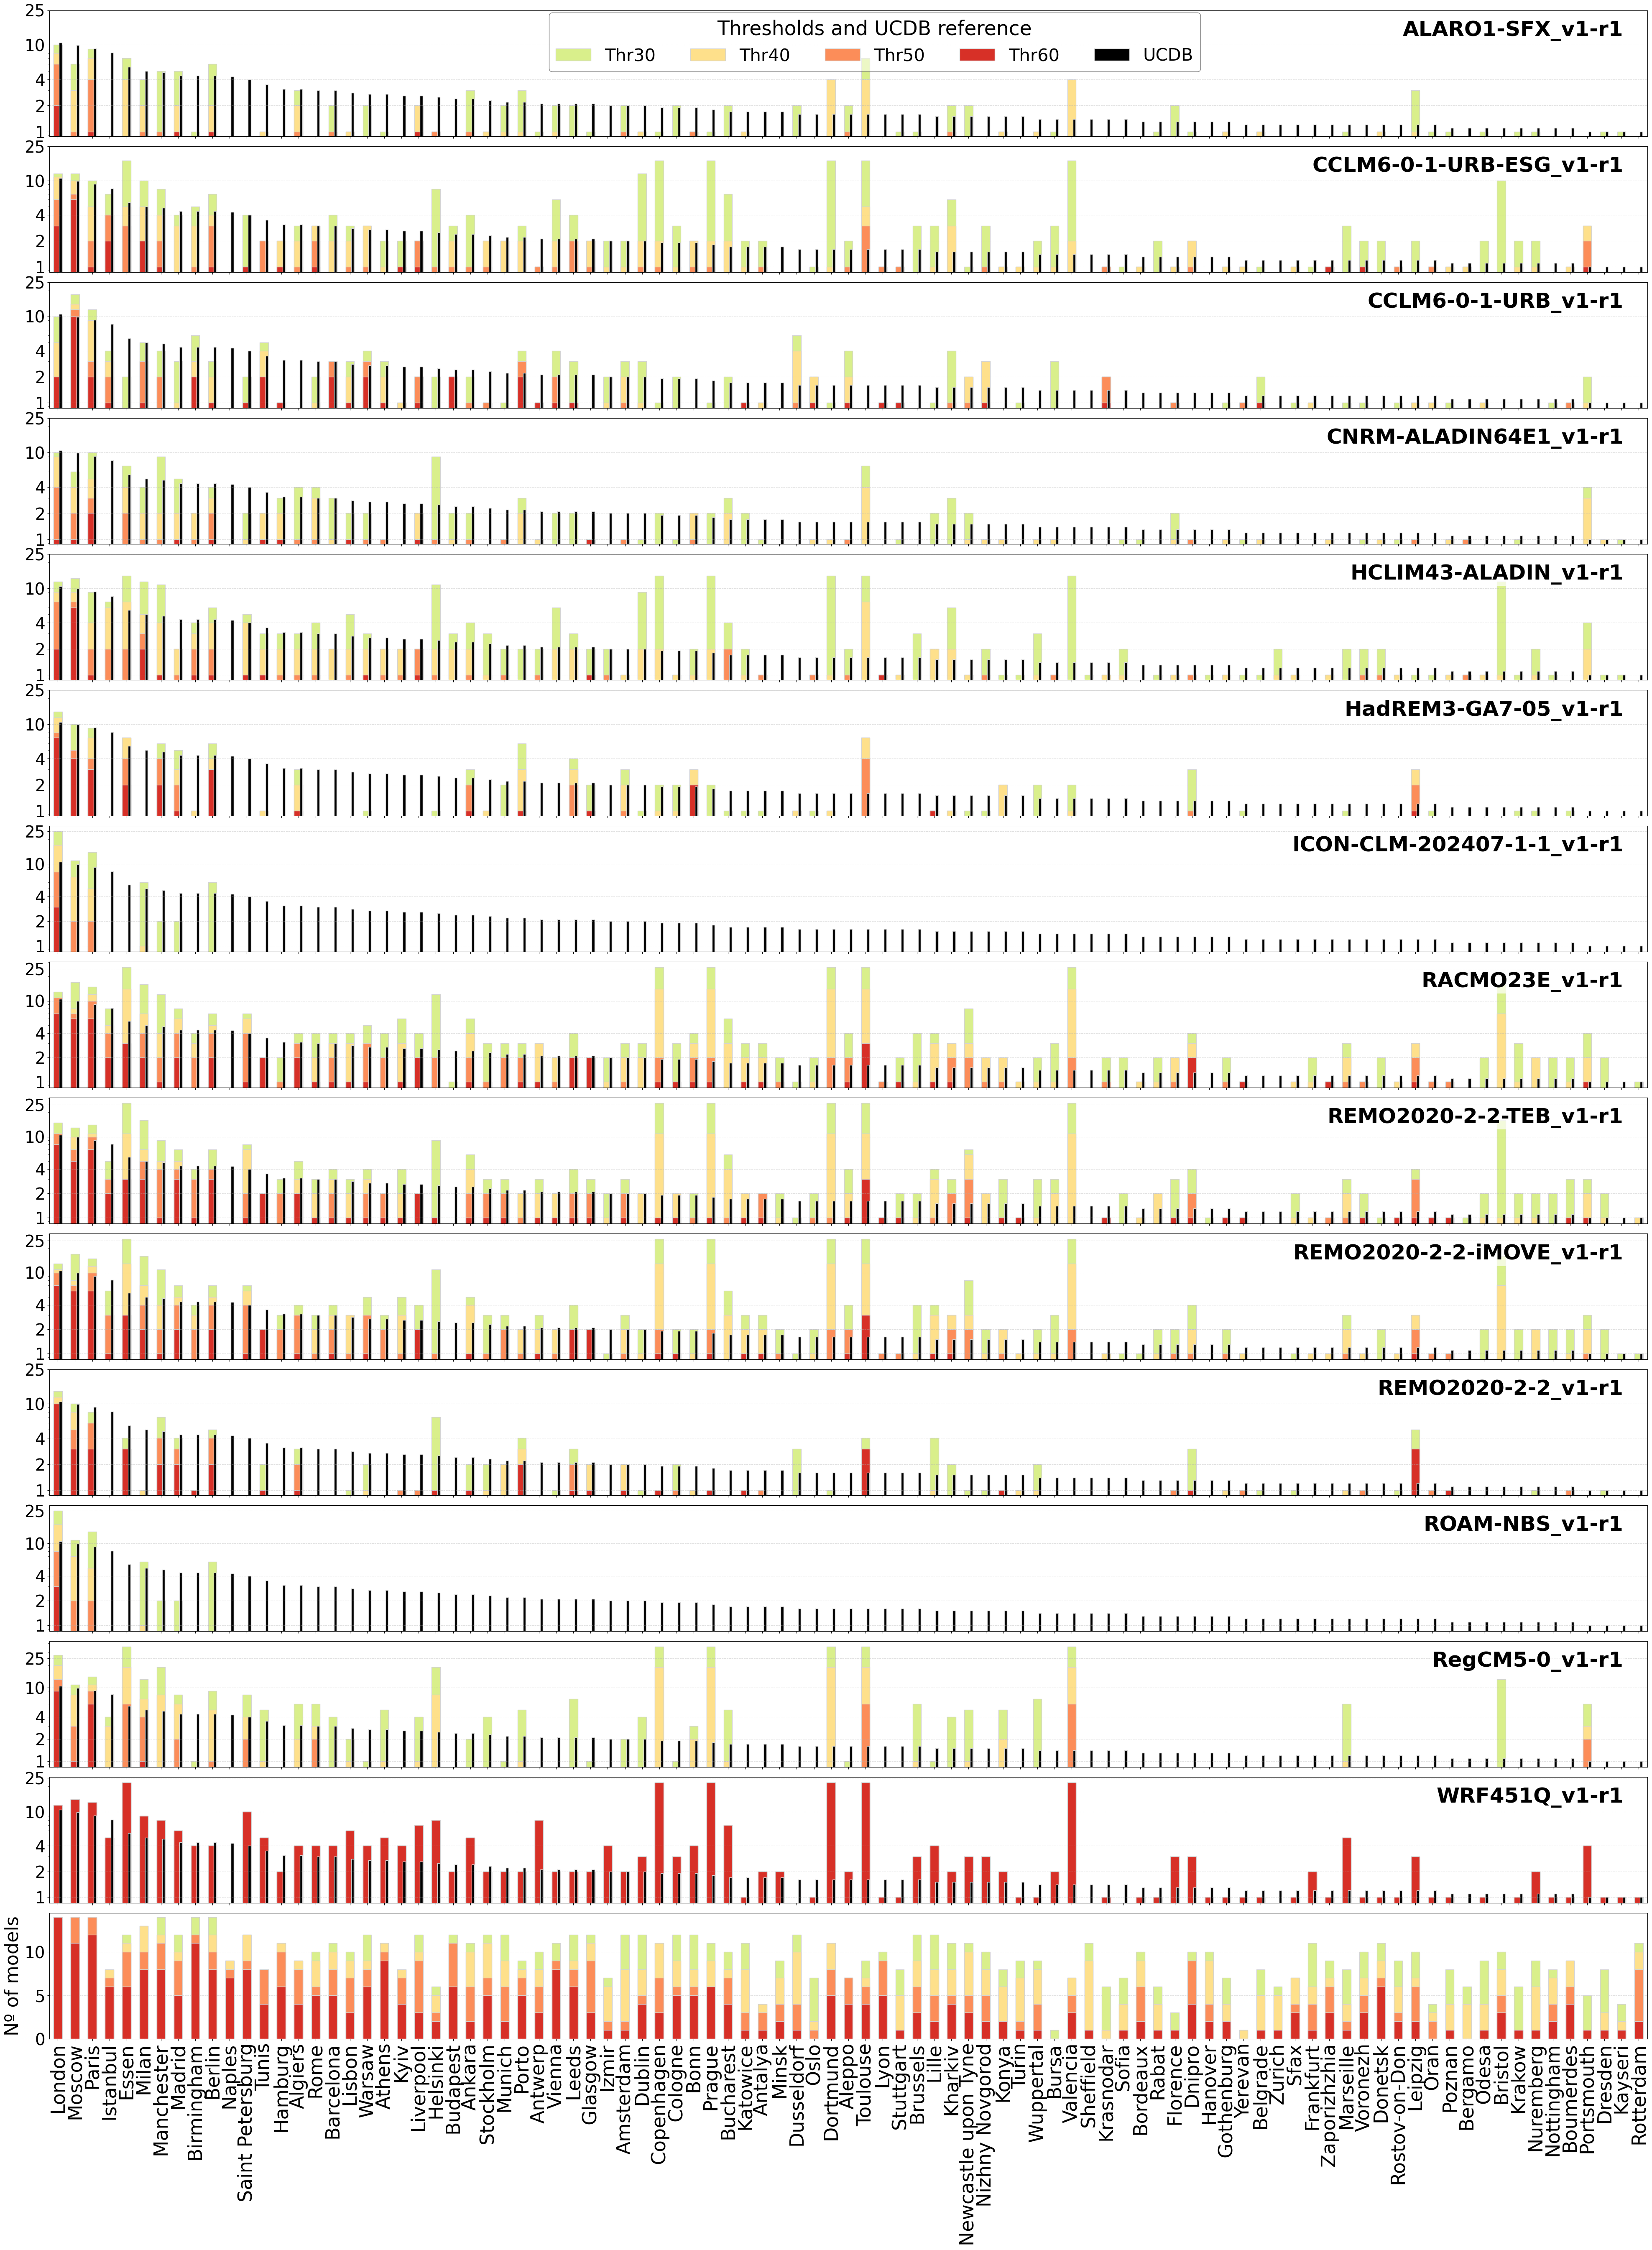

In [23]:
plot_urban_cells_all_models_with_summary(
    df=df,
    df_all=df_all,
    thresholds=thresholds,
    ucdb_series=ucdb_series,
    global_order=global_order,
    city_labels=city_labels,
    plot_folder=plot_folder
)